In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import pandas as pd

# Lecture 9: Kidney Cancer Data Analysis

This is an example on "Bayesian Disease Mapping", and is taken from Section 2.7 on estimation of kidney cancer rates of the book "Bayesian Data Analysis Edition 3" by Gelman et al. Some of the code is taken from a blog post by Robin Ryder (google this). Consider the following dataset. 

In [4]:
#Read the kidney cancer dataset
d_full = pd.read_csv("KidneyCancerClean.csv", skiprows=4)
display(d_full.head(15))
summary = d_full.describe(include = 'all')
display(summary)

,Unnamed: 0,state,Location,fips,dc,dcV,pop,popV,aadc,aadcV,...,good,dc.2,dcV.2,pop.2,popV.2,aadc.2,aadcV.2,dcC.2,dcCV.2,good.2
0,108,ALABAMA,"Autauga County, Alabama",1001,2,VALID,61921,VALID,3.3,UNRELIABLE,...,1,1,VALID,64915,VALID,1.7,UNRELIABLE,1.5,UNRELIABLE,1
1,117,ALABAMA,"Baldwin County, Alabama",1003,7,VALID,170945,VALID,3.5,UNRELIABLE,...,1,15,VALID,195253,VALID,6.3,UNRELIABLE,7.7,UNRELIABLE,1
2,129,ALABAMA,"Barbour County, Alabama",1005,0,VALID,33316,VALID,0.0,UNRELIABLE,...,1,1,VALID,33987,VALID,2.6,UNRELIABLE,2.9,UNRELIABLE,1
3,199,ALABAMA,"Bibb County, Alabama",1007,0,VALID,30152,VALID,0.0,UNRELIABLE,...,1,1,VALID,31175,VALID,2.9,UNRELIABLE,3.2,UNRELIABLE,1
4,219,ALABAMA,"Blount County, Alabama",1009,3,VALID,88342,VALID,3.2,UNRELIABLE,...,1,5,VALID,91547,VALID,4.8,UNRELIABLE,5.5,UNRELIABLE,1
5,306,ALABAMA,"Bullock County, Alabama",1011,0,VALID,8313,VALID,0.0,UNRELIABLE,...,1,0,VALID,8197,VALID,0.0,UNRELIABLE,0.0,UNRELIABLE,1
6,318,ALABAMA,"Butler County, Alabama",1013,0,VALID,31963,VALID,0.0,UNRELIABLE,...,1,1,VALID,31722,VALID,2.8,UNRELIABLE,3.2,UNRELIABLE,1
7,343,ALABAMA,"Calhoun County, Alabama",1015,9,VALID,243105,VALID,4.0,UNRELIABLE,...,1,12,VALID,233021,VALID,5.4,UNRELIABLE,5.1,UNRELIABLE,1
8,439,ALABAMA,"Chambers County, Alabama",1017,7,VALID,59985,VALID,8.3,UNRELIABLE,...,1,0,VALID,57813,VALID,0.0,UNRELIABLE,0.0,UNRELIABLE,1
9,467,ALABAMA,"Cherokee County, Alabama",1019,0,VALID,43401,VALID,0.0,UNRELIABLE,...,1,0,VALID,43828,VALID,0.0,UNRELIABLE,0.0,UNRELIABLE,1


,Unnamed: 0,state,Location,fips,dc,dcV,pop,popV,aadc,aadcV,...,good,dc.2,dcV.2,pop.2,popV.2,aadc.2,aadcV.2,dcC.2,dcCV.2,good.2
count,3110.000000,3110,3110,3110.000000,3110.000000,3110,3.110000e+03,3110,3110.000000,3110,...,3110.000000,3110.000000,3110,3.110000e+03,3110,3110.000000,3110,3109.000000,3109,3110.000000
unique,NaN,50,3109,NaN,NaN,1,NaN,1,NaN,2,...,NaN,NaN,1,NaN,1,NaN,3,NaN,2,NaN
top,NaN,TEXAS,"Bedford County, Virginia",NaN,NaN,VALID,NaN,VALID,NaN,UNRELIABLE,...,NaN,NaN,VALID,NaN,VALID,NaN,UNRELIABLE,NaN,UNRELIABLE,NaN
freq,NaN,254,2,NaN,NaN,3110,NaN,3110,NaN,2882,...,NaN,NaN,3110,NaN,3110,NaN,2848,NaN,2848,NaN
mean,1555.500000,NaN,NaN,30672.690675,7.527974,NaN,1.550087e+05,NaN,4.438392,NaN,...,0.985852,8.359164,NaN,1.606611e+05,NaN,4.834244,NaN,5.787359,NaN,0.985852
std,897.923995,NaN,NaN,14980.587745,23.095402,NaN,4.722345e+05,NaN,3.501390,NaN,...,0.118120,23.765728,NaN,4.972750e+05,NaN,3.709540,NaN,5.030156,NaN,0.118120
min,1.000000,NaN,NaN,1001.000000,0.000000,NaN,2.580000e+02,NaN,0.000000,NaN,...,0.000000,0.000000,NaN,2.670000e+02,NaN,0.000000,NaN,0.000000,NaN,0.000000
25%,778.250000,NaN,NaN,19041.500000,1.000000,NaN,2.238250e+04,NaN,2.100000,NaN,...,1.000000,1.000000,NaN,2.213000e+04,NaN,2.525000,NaN,2.800000,NaN,1.000000
50%,1555.500000,NaN,NaN,29210.000000,2.000000,NaN,4.762800e+04,NaN,4.300000,NaN,...,1.000000,3.000000,NaN,4.806950e+04,NaN,4.600000,NaN,5.200000,NaN,1.000000
75%,2332.750000,NaN,NaN,46008.500000,6.000000,NaN,1.146262e+05,NaN,6.100000,NaN,...,1.000000,7.000000,NaN,1.179355e+05,NaN,6.600000,NaN,7.700000,NaN,1.000000


This is county-level data on population and deaths due to kidney cancer. There are quite a few columns in the dataset but we shall only work with the four columns: dc, dc.2, pop and pop.2:

1. The columns dc and dc.2 represent death counts due to kidney cancer in 1980-84 and 1985-89 respectively. 
2. The columns pop and pop.2 represent some measure of the average population in 1980-84 and 1985-89 respectively. 

Let us create a smaller dataframe with only these columns. 

In [5]:
d = d_full[['state', 'Location', 'fips', 'dc', 'pop', 'dc.2', 'pop.2']].copy()
display(d.head(20))

,state,Location,fips,dc,pop,dc.2,pop.2
0,ALABAMA,"Autauga County, Alabama",1001,2,61921,1,64915
1,ALABAMA,"Baldwin County, Alabama",1003,7,170945,15,195253
2,ALABAMA,"Barbour County, Alabama",1005,0,33316,1,33987
3,ALABAMA,"Bibb County, Alabama",1007,0,30152,1,31175
4,ALABAMA,"Blount County, Alabama",1009,3,88342,5,91547
5,ALABAMA,"Bullock County, Alabama",1011,0,8313,0,8197
6,ALABAMA,"Butler County, Alabama",1013,0,31963,1,31722
7,ALABAMA,"Calhoun County, Alabama",1015,9,243105,12,233021
8,ALABAMA,"Chambers County, Alabama",1017,7,59985,0,57813
9,ALABAMA,"Cherokee County, Alabama",1019,0,43401,0,43828


The purpose of this data analysis is to estimate the kidney cancer death rates for each county and, more importantly, **to flag the counties with high kidney cancer death rates**. Before proceeding to the analysis, let us first combine the death counts for the two periods 80-84 and 85-89 to get one overall death count for each county. Further, let us take the average of pop and pop.2 to get a measure of the average population of each county in the period 80-89. 

In [6]:
# Combine the death and population counts for the two periods 80-84 and 85-89
d['dct'] = d['dc'] + d['dc.2'] #dct stands for death count total
d['popm'] = (d['pop'] + d['pop.2']) / 2
display(d.head(15))

,state,Location,fips,dc,pop,dc.2,pop.2,dct,popm
0,ALABAMA,"Autauga County, Alabama",1001,2,61921,1,64915,3,63418.0
1,ALABAMA,"Baldwin County, Alabama",1003,7,170945,15,195253,22,183099.0
2,ALABAMA,"Barbour County, Alabama",1005,0,33316,1,33987,1,33651.5
3,ALABAMA,"Bibb County, Alabama",1007,0,30152,1,31175,1,30663.5
4,ALABAMA,"Blount County, Alabama",1009,3,88342,5,91547,8,89944.5
5,ALABAMA,"Bullock County, Alabama",1011,0,8313,0,8197,0,8255.0
6,ALABAMA,"Butler County, Alabama",1013,0,31963,1,31722,1,31842.5
7,ALABAMA,"Calhoun County, Alabama",1015,9,243105,12,233021,21,238063.0
8,ALABAMA,"Chambers County, Alabama",1017,7,59985,0,57813,7,58899.0
9,ALABAMA,"Cherokee County, Alabama",1019,0,43401,0,43828,0,43614.5


A simple way to estimate the kidney cancer rate of each county is to use the proportion: 
\begin{align*}
\text{Naive Estimate of Kidney Cancer Death Rate} =  \frac{\text{Number of Kidney Cancer Deaths}}{\text{Population}}
\end{align*}
We can then rank all the counties according to their naive proportions and flag the counties for whom the naive proportion is high. 

count    3110.000000
mean        0.000108
std         0.000068
min         0.000000
25%         0.000067
50%         0.000100
75%         0.000139
max         0.000691
Name: naiveproportion, dtype: float64


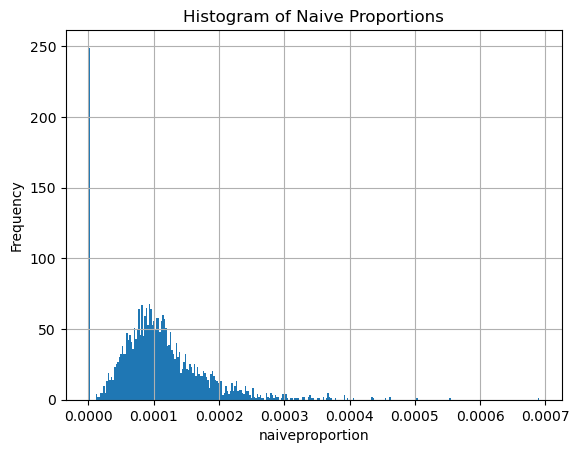

In [7]:
d['naiveproportion'] = d['dct'] / d['popm']
summary = d['naiveproportion'].describe()
print(summary)
#Histogram of naive proportion estimates:
import matplotlib.pyplot as plt
plt.hist(d['naiveproportion'], bins=300)
plt.xlabel('naiveproportion')
plt.ylabel('Frequency')
plt.title('Histogram of Naive Proportions')
plt.grid(True)
plt.show()
#Some observations on the histogram: 
#There is a spike at zero (corresponding to counties with no kidney cancer deaths)
#Most proportions are around 0.0001 but there are a few counties which have large proportions (more than 0.0004)

In [8]:
#Flagging Counties with High Kidney Cancer Death Proportions. 
#One way to do this is to get the counties with the 100 highest naive proportion:
threshold = d['naiveproportion'].nlargest(100).iloc[-1]
print(threshold)

d['cancerhigh'] = d['naiveproportion'] >= threshold
with pd.option_context('display.max_rows', None):
    display(d[d['cancerhigh'] >= True])

0.00025143527636927463


,state,Location,fips,dc,pop,dc.2,pop.2,dct,popm,naiveproportion,cancerhigh
65,ALABAMA,"Wilcox County, Alabama",1131,2,11144,1,10727,3,10935.5,0.000274,True
148,ARKANSAS,"Sharp County, Arkansas",5135,4,34922,5,33806,9,34364.0,0.000262,True
149,ARKANSAS,"Stone County, Arkansas",5137,1,22387,5,23148,6,22767.5,0.000264,True
230,COLORADO,"Dolores County, Colorado",8033,1,4151,1,3797,2,3974.0,0.000503,True
473,GEORGIA,"Quitman County, Georgia",13239,0,2524,1,2557,1,2540.5,0.000394,True
485,GEORGIA,"Talbot County, Georgia",13263,1,5855,1,6008,2,5931.5,0.000337,True
495,GEORGIA,"Treutlen County, Georgia",13283,1,9944,3,9695,4,9819.5,0.000407,True
512,GEORGIA,"Wilkes County, Georgia",13317,3,14334,1,14223,4,14278.5,0.000280,True
535,IDAHO,"Clark County, Idaho",16033,1,2212,0,2176,1,2194.0,0.000456,True
549,IDAHO,"Lewis County, Idaho",16061,2,9705,1,8634,3,9169.5,0.000327,True


In [9]:
#It will be cool to plot the high cancer counties (in terms of the naive proportions) on the US map
#This can be done in the following way.
import plotly.express as px
#First convert fips to standard form:
d['modfips'] = d['fips'].apply(lambda x: str(x).zfill(5))
#Plotting the counties with high cancer proportion:
fig = px.choropleth(
    d, 
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json", # This is a dataset containing county geometries
    locations='modfips', # Use the 'fips' column for county identification
    color='cancerhigh',
    hover_name='Location',  # Display the 'Location' column on hover
    scope="usa",
    title="Top 100 kidney cancer death rate counties (in terms of naive proportions)",
    color_continuous_scale="YlOrRd"
)
fig.update_geos(fitbounds="locations")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

Question: Is this a good way of flagging the high kidney cancer rate counties? Should we now look into specific reasons (such as dietary patterns, pollution etc, lack of access to quality medical care etc.) why these  counties have high rates? 

It turns out that this analysis is misleading because of the use of naive proportions as estimates of kidney cancer death rates. In particular, the counties that we flagged are mostly counties with low populations. This can be understood as follows. The typical rate of kidney cancer is about 0.0001 as can be seen, for example, from the naive proportion estimates of counties with large populations. 

In [10]:
sorted_populations = d['popm'].sort_values()
print(list(sorted_populations))
#Select counties with large populations
#By large population, let us take populations more than 300000
largecounties = d[d['popm'] >= 300000]
largecounties.shape[0]
#So there are 323 counties with population more than 300000
#Let us evaluate the naive proportions for these counties. 
summary = d[d['popm'] >= 300000]['naiveproportion'].describe()
display(summary)
#the mean and median are about 0.0001 which can therefore be viewed as a typical value of the kidney cancer rate

[262.5, 978.0, 1017.0, 1139.0, 1233.5, 1268.0, 1297.0, 1448.0, 1570.5, 1594.0, 1640.5, 1862.5, 1879.0, 1942.0, 1946.5, 2058.5, 2108.0, 2160.5, 2171.0, 2175.5, 2194.0, 2250.0, 2296.0, 2337.0, 2342.5, 2353.0, 2358.5, 2473.5, 2522.5, 2540.5, 2542.5, 2547.5, 2570.5, 2731.0, 2731.5, 2817.5, 2866.5, 3005.5, 3027.0, 3095.0, 3102.5, 3268.5, 3294.5, 3305.0, 3433.0, 3434.0, 3532.5, 3556.5, 3583.0, 3596.5, 3616.0, 3629.0, 3819.0, 3974.0, 4044.5, 4076.0, 4129.0, 4182.0, 4188.5, 4224.0, 4341.5, 4342.5, 4349.0, 4351.0, 4448.5, 4449.5, 4450.0, 4465.0, 4487.0, 4493.5, 4518.5, 4527.5, 4571.5, 4600.5, 4632.5, 4695.5, 4715.5, 4784.5, 4832.0, 4836.5, 4952.0, 4956.5, 5169.0, 5177.5, 5236.0, 5256.5, 5268.0, 5282.0, 5284.5, 5309.5, 5311.5, 5343.5, 5359.0, 5391.0, 5404.5, 5407.5, 5424.5, 5435.5, 5478.0, 5529.5, 5594.0, 5596.5, 5602.5, 5619.0, 5712.0, 5730.0, 5743.0, 5786.0, 5789.5, 5808.0, 5849.0, 5853.5, 5899.0, 5902.0, 5905.0, 5916.0, 5925.5, 5931.5, 6012.5, 6034.5, 6097.0, 6111.0, 6115.0, 6236.0, 6315.0, 6

count    323.000000
mean       0.000098
std        0.000029
min        0.000034
25%        0.000081
50%        0.000095
75%        0.000115
max        0.000227
Name: naiveproportion, dtype: float64

Now we can explain why our initial flagged set of high cancer rate counties is dominated by counties with low populations. Consider a county with a small population of 1000. In the given ten-year period, suppose this county has 1 kidney cancer death. The naive proportion would then be 1/1000 = 0.001 which is already 10 times the typical rate of 0.0001. So this county would immediately be flagged as a high cancer rate county just because of the single death. Go back to our flagged list of high population counties and check the population sizes. 

In [11]:
d[d['naiveproportion'] >= threshold]['popm'].describe()

count      100.000000
mean     16940.950000
std      11922.792393
min       1448.000000
25%       8442.625000
50%      14204.250000
75%      21550.375000
max      60380.500000
Name: popm, dtype: float64

The county with the largest population in this list is 60000 but there are counties with population as small as 1448. So this entire list of high kidney cancer rate counties is dominated by counties with small populations. 

Note that there are many large counties (e.g., with population more than 300000) in the dataset. 

In [12]:
#Summary statistics of counties with population more than 300000:
print(d[d['popm'] >= 300000]['popm'].describe())
print(d.shape)
#So there are 323 counties with population more than 300000 (total number of counties in the dataset is 3110). 

count    3.230000e+02
mean     9.672240e+05
std      1.224408e+06
min      3.024855e+05
25%      4.001872e+05
50%      6.118650e+05
75%      1.091832e+06
max      1.593715e+07
Name: popm, dtype: float64
(3110, 12)


## Bayesian estimates of the kidney cancer death rates

For Bayesian estimates, we need an appropriate prior. One way of obtaining such a prior is to consider the naive proportions of the large population counties (say, with population at least 300000) and to fit a Beta density to the naive proportions. This can be done via mean and variance as follows.

In [13]:
proportions_largecounties = d['naiveproportion'][d['popm'] >= 300000] #filter out the high population counties
mean_largecounties = np.mean(proportions_largecounties)
var_largecounties = np.var(proportions_largecounties)
print(mean_largecounties, var_largecounties)

9.813238615946435e-05 8.172661645662482e-10


For what values of $a$ and $b$ would the $\text{Beta}(a, b)$ density have mean $m$ and variance $V$. To answer this, we need to basically solve
\begin{align*}
  \frac{a}{a+b} = m ~~ \text{ and } ~~ \frac{a}{a+b} \frac{b}{a+b} \frac{1}{a+b+1} = V. 
\end{align*}
Plugging $m$ for $\frac{a}{a+b}$ and $1-m$ for $\frac{b}{a+b}$ in the second equation, we obtain
\begin{align*}
  \frac{m(1-m)}{a+b+1} = V \implies a+b = \frac{m(1-m)}{V} - 1. 
\end{align*}
Combining this with $\frac{a}{a+b} = m$, we obtain
\begin{align*}
   a = m\left(\frac{m(1-m)}{V} - 1 \right) ~~~ \text{ and } ~~~ b = (1-m)\left(\frac{m(1-m)}{V} - 1 \right)
\end{align*}
Of course, $m$ and $V$ should be such that $a$ and $b$ as computed above should be strictly bigger than zero. If not, this method of figuring out $a$ and $b$ using mean and variance does not work. 

In [14]:
#Using the above formula, we obtain
m = mean_largecounties
V = var_largecounties
ahat = ((m*m*(1-m))/V) - m
bhat = (((1-m)*(1-m)*m)/V) - (1-m)
a = ahat
b = bhat
print(a, b)

11.781889938777498 120049.39668603126


Note that here $a$ is much smaller than $b$ which means that the Beta density will be concentrated on very small values (this makes sense because this is intended to be a prior for the kidney cancer rate which we believe to be small with typical values around 0.0001). 

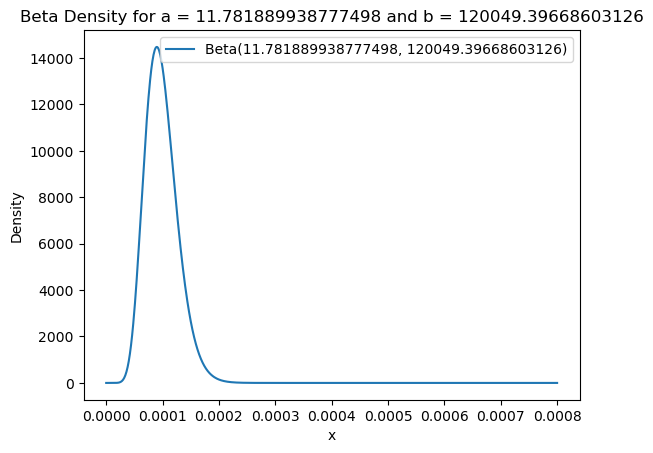

In [15]:
#Plot of this Beta density
x = np.arange(0, 8e-4, 1e-6)
y = beta.pdf(x, a, b)
plt.plot(x, y, label = f"Beta({a}, {b})")
plt.title(f'Beta Density for a = {a} and b = {b}')
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

We now compute the Bayesian estimates of kidney cancer death rates. For a county with population $POP$ and death count $DC$, our posterior density of the rate would be
\begin{align*}
  \text{Beta}(a + DC, b + POP - DC)
\end{align*}
Thus the posterior mean (which will be our Bayesian estimate of the kidney cancer death rate) is 
\begin{align*}
  \frac{a + DC}{a + b + POP}. 
\end{align*}

In [16]:
d['bayes1'] = (a + d['dct']) / (a + b + d['popm'])
#We can now flag the top 100 counties using the Bayesian estimate:
threshold = d['bayes1'].nlargest(100).iloc[-1]
d['bayeshigh1'] = d['bayes1'] >= threshold
#Let us look at these counties to see if they are different from the previous flagged list:
with pd.option_context('display.max_rows', None):
    display(d[d['bayeshigh1'] >= True])

,state,Location,fips,dc,pop,dc.2,pop.2,dct,popm,naiveproportion,cancerhigh,modfips,bayes1,bayeshigh1
61,ALABAMA,"Tallapoosa County, Alabama",1123,8,67871,7,68002,15,67936.5,0.000221,False,01123,0.000142,True
71,ARIZONA,"Graham County, Arizona",4009,7,51342,6,53873,13,52607.5,0.000247,False,04009,0.000144,True
74,ARIZONA,"Mohave County, Arizona",4015,8,149437,22,189941,30,169689.0,0.000177,False,04015,0.000144,True
79,ARIZONA,"Yavapai County, Arizona",4025,14,176766,21,223856,35,200311.0,0.000175,False,04025,0.000146,True
106,ARKANSAS,"Garland County, Arkansas",5051,10,154925,18,158622,28,156773.5,0.000179,False,05051,0.000144,True
148,ARKANSAS,"Sharp County, Arkansas",5135,4,34922,5,33806,9,34364.0,0.000262,True,05135,0.000135,True
172,CALIFORNIA,"Lake County, California",6033,12,93785,11,109600,23,101692.5,0.000226,False,06033,0.000157,True
183,CALIFORNIA,"Napa County, California",6055,13,236568,29,247143,42,241855.5,0.000174,False,06055,0.000149,True
280,CONNECTICUT,"Middlesex County, Connecticut",9007,20,304656,35,320284,55,312470.0,0.000176,False,09007,0.000154,True
294,FLORIDA,"Broward County, Florida",12011,197,2212734,207,2381166,404,2296950.0,0.000176,False,12011,0.000172,True


Clearly now there are many counties with large populations in the list. The list of counties flagged as 'high rate counties' by the Bayesian method is quite different from the corresponding list by the naive frequentist proportions. 

In [17]:
#Table of the top 100 counties flagged by the naive proportion and the Bayesian estimate:
#2 by 2 cross-tabulation of the two lists:
ct = pd.crosstab(d['cancerhigh'], d['bayeshigh1'])
display(ct)
#There are only 18 (out of 100) counties that are flagged by both the naive and the Bayesian method.

bayeshigh1,False,True
cancerhigh,,
False,2928,82
True,82,18


Here is a plot of the high Bayesian estimate counties on the US map. 

In [18]:
#Plotting counties with high Bayesian estimates of kidney cancer rates on the US map
import plotly.express as px
#First convert fips to standard form:
d['modfips'] = d['fips'].apply(lambda x: str(x).zfill(5))
#Plotting the counties with high cancer proportion:

fig = px.choropleth(
    d, 
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json", # This is a dataset containing county geometries
    locations='modfips', # Use the 'fips' column for county identification
    color='bayeshigh1',
    hover_name='Location',  # Display the 'Location' column on hover
    scope="usa",
    title="Top 100 kidney cancer death rate counties (in terms of Bayes estimates)",
    color_continuous_scale="YlOrRd"
)
fig.update_geos(fitbounds="locations")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

Here are both plots superimposed. 

In [19]:
d['category'] = "Neither"
d.loc[d['bayeshigh1'] & ~d['cancerhigh'], 'category'] = "Bayes only"
d.loc[~d['bayeshigh1'] & d['cancerhigh'], 'category'] = "Naive only"
d.loc[d['bayeshigh1'] & d['cancerhigh'], 'category'] = "Both"
fig = px.choropleth(
    d,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='modfips',
    color='category',
    scope="usa",
    hover_name='Location',
    color_discrete_map={
        "Bayes only": "crimson",
        "Naive only": "dodgerblue",
        "Both": "lime",        # 🔥 bright green
        "Neither": "lightgray"
    }
)

fig.update_geos(fitbounds="locations")
fig.show()


In [20]:
#Look at the states for the high counties (under both the naive and Bayes estimates)
counts = d.groupby('state').agg({'cancerhigh': 'sum', 'bayeshigh1': 'sum'})
print(counts)

                      cancerhigh  bayeshigh1
state                                       
ALABAMA                        1           1
ARIZONA                        0           3
ARKANSAS                       2           2
CALIFORNIA                     0           2
COLORADO                       1           0
CONNECTICUT                    0           1
DELAWARE                       0           0
DISTRICT.OF.COLUMBIA           0           0
FLORIDA                        0          14
GEORGIA                        4           0
HAWAII                         0           0
IDAHO                          2           0
ILLINOIS                       3           6
INDIANA                        0           2
IOWA                           5           6
KANSAS                         6           3
KENTUCKY                       2           1
LOUISIANA                      0           3
MAINE                          0           0
MARYLAND                       0           1
MASSACHUSE

Clearly, there are quite many differences between the two estimates. 

Let us now see how the Bayes rule converts prior to posterior for some specific counties.

In [21]:
#Consider the county in row 1681 of the dataset:
print(d.iloc[1681])

state                                NEBRASKA
Location           McPherson County, Nebraska
fips                                    31117
dc                                          0
pop                                      1504
dc.2                                        1
pop.2                                    1392
dct                                         1
popm                                   1448.0
naiveproportion                      0.000691
cancerhigh                               True
modfips                                 31117
bayes1                               0.000105
bayeshigh1                              False
category                           Naive only
Name: 1681, dtype: object


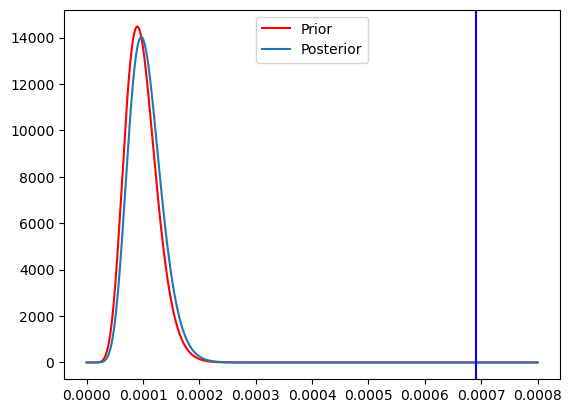

In [22]:
#This county has low population (1448) with one death. The naive proportion is 0.000691 (which is roughly seven times the typical value of 0.0001)
#So this has been flagged as a high risk county by the naive estimate
#This is NOT a high risk county according to the Bayesian estimate
#Below we plot the prior and the posterior for this county to see why this is the case.
x = np.arange(0, 8e-4, 1e-6)
Tot = round(d.loc[1681, 'popm'])
Pos = d.loc[1681, 'dct']
Neg = Tot - Pos
plt.plot(x, beta.pdf(x, a, b), color = 'red', label = 'Prior')
plt.plot(x, beta.pdf(x, a + Pos, b + Neg), label = 'Posterior')
plt.axvline(x = Pos/Tot, color = 'blue') #line at the naive proportion
plt.legend()
plt.show()
#Basically there is very little difference between the prior and the posterior
#In other words, the Bayesian posterior is largely ignoring the "review" data and only going by the prior
#This makes sense because there is not much information from the observed count for such a small county.

state                             NEBRASKA
Location           Arthur County, Nebraska
fips                                 31005
dc                                       0
pop                                   1295
dc.2                                     0
pop.2                                 1172
dct                                      0
popm                                1233.5
naiveproportion                        0.0
cancerhigh                           False
modfips                              31005
bayes1                            0.000097
bayeshigh1                           False
category                           Neither
Name: 1624, dtype: object


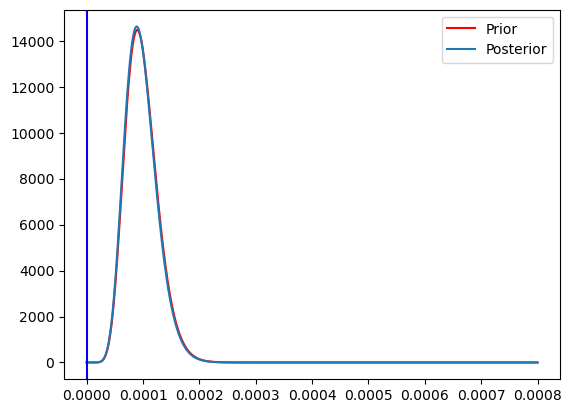

In [23]:
#Next let us look at the county in row 1624. This is Arthur County again Nebraska
#It has a small population of 1233 and death count of 0. 
print(d.iloc[1624])
x = np.arange(0, 8e-4, 1e-6)
Tot = round(d.loc[1624, 'popm'])
Pos = d.loc[1624, 'dct']
Neg = Tot - Pos
plt.plot(x, beta.pdf(x, a, b), color = 'red', label = 'Prior')
plt.plot(x, beta.pdf(x, a + Pos, b + Neg), label = 'Posterior')
plt.axvline(x = Pos/Tot, color = 'blue') #line at the naive proportion
plt.legend()
plt.show()
#Similar story here; not much difference between prior and posterior

Now let us look at an example of a county which was flagged by the Bayesian analysis but not by the frequentist analysis. 

state                               FLORIDA
Location           Sarasota County, Florida
fips                                  12115
dc                                       55
pop                                  485595
dc.2                                     65
pop.2                                573711
dct                                     120
popm                               529653.0
naiveproportion                    0.000227
cancerhigh                            False
modfips                               12115
bayes1                             0.000203
bayeshigh1                             True
category                         Bayes only
Name: 346, dtype: object


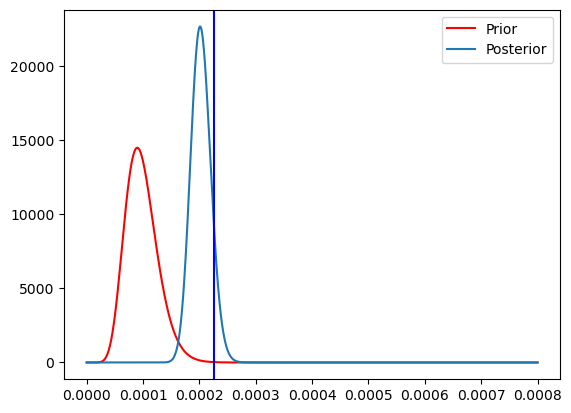

In [24]:
print(d.iloc[346])
#This is a large county (population around half a million) and a large death count (120)
x = np.arange(0, 8e-4, 1e-6)
Tot = round(d.loc[346, 'popm'])
Pos = d.loc[346, 'dct']
Neg = Tot - Pos
plt.plot(x, beta.pdf(x, a, b), color = 'red', label = 'Prior')
plt.plot(x, beta.pdf(x, a + Pos, b + Neg), label = 'Posterior')
plt.axvline(x = Pos/Tot, color = 'blue') #line at the naive proportion
plt.legend()
plt.show()
#The Bayesian posterior moves quite a bit in the direction of the frequentist estimate
#The frequentist analysis does not flag this as a high-risk county because there were many low population counties
#which dominated its proportion. 

Bayesian estimates are often said to perform "Shrinkage". They shrink the frequentist estimates towards the prior. Overall, the variability of Bayesian estimates will be quite a bit smaller compared to frequentist estimates. 

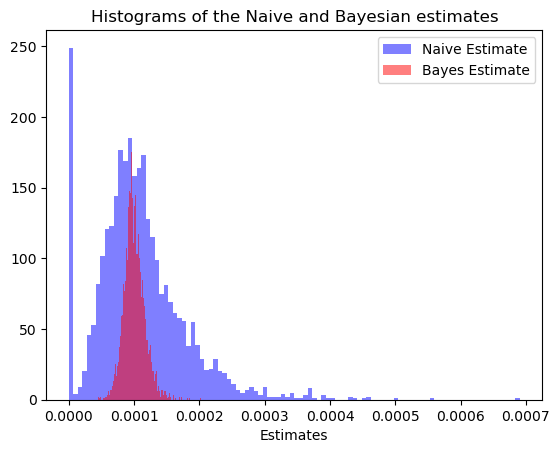

In [25]:
h1, _, _ = plt.hist(d['naiveproportion'], bins=100, color='blue', label='Naive Estimate', alpha=0.5)
h2, _, _ = plt.hist(d['bayes1'], bins=100, color='red', label='Bayes Estimate', alpha=0.5)

plt.title("Histograms of the Naive and Bayesian estimates")
plt.xlabel("Estimates")
plt.legend() 
plt.show()

This shrinkage is one reason why the Bayes method was able to flag Sarasota County, Florida as a high risk county even though its estimate was only 0.000203; this was already extreme compared to the rest of the Bayesian estimates (but not extreme relative to naive proportions).  

Recall that the original dataset had two time periods 80-84 and 85-89. We now repeat the analysis only for the first time period and attempt to predict the proportions for the second time period. We can compare the performances of the naive proportions and the Bayes estimates in this prediction problem.

In [26]:
d['naiveproportion1'] = d['dc'] / d['pop'] #these are the naive estimates

#For the Bayes estimates, we first need to estimate the prior:
proportions1_largecounties = d['naiveproportion1'][d['pop'] >= 300000] #filter out the high population counties
m1 = np.mean(proportions1_largecounties)
V1 = np.var(proportions1_largecounties)
a1 = ((m1*m1*(1-m1))/V1) - m1
b1 = (((1-m1)*(1-m1)*m1)/V1) - (1-m1)

d['bayesestimate1'] = (d['dc'] + a1)/(d['pop'] + a1 + b1)

#Proportions from the second half of the data:
d['proportion2'] = d['dc.2'] / d['pop.2']

#Prediction Accuracy:
diff_naiveproportion1 = d['naiveproportion1'] - d['proportion2']
sum_abs_diff_naiveproportion1 = diff_naiveproportion1.abs().sum()
sum_squared_diff_naiveproportion1 = (diff_naiveproportion1**2).sum()
kl_loss_naiveproportion1 = (d['proportion2'] * np.log(d['proportion2'] / (d['naiveproportion1'] + 1e-10) + 1e-10)).sum() + ((1 - d['proportion2']) * np.log((1 - d['proportion2']) / (1 - d['naiveproportion1'] + 1e-10) + 1e-10)).sum()
negloglik_naiveproportion1 = -(d['dc.2'] * np.log(d['naiveproportion1'] + 1e-10)).sum() - ((d['pop.2'] - d['dc.2']) * np.log(1 - d['naiveproportion1'] + 1e-10)).sum()


diff_bayesestimate1 = d['bayesestimate1'] - d['proportion2']
sum_abs_diff_bayesestimate1 = diff_bayesestimate1.abs().sum()
sum_squared_diff_bayesestimate1 = (diff_bayesestimate1**2).sum()
kl_loss_bayesestimate1 = (d['proportion2'] * np.log(d['proportion2'] / (d['bayesestimate1'] + 1e-10) + 1e-10)).sum() + ((1 - d['proportion2']) * np.log((1 - d['proportion2']) / (1 - d['bayesestimate1'] + 1e-10) + 1e-10)).sum()
negloglik_bayesestimate1 = -(d['dc.2'] * np.log(d['bayesestimate1'] + 1e-10)).sum() - ((d['pop.2'] - d['dc.2']) * np.log(1 - d['bayesestimate1'] + 1e-10)).sum() 

bothresults_absdiff = np.array([sum_abs_diff_naiveproportion1, sum_abs_diff_bayesestimate1])
bothresults_squareddiff = np.array([sum_squared_diff_naiveproportion1, sum_squared_diff_bayesestimate1])
bothresults_klloss = np.array([kl_loss_naiveproportion1, kl_loss_bayesestimate1])
bothresults_negloglik = np.array([negloglik_naiveproportion1, negloglik_bayesestimate1])
print(bothresults_absdiff)
print(bothresults_squareddiff)
print(bothresults_klloss)
print(bothresults_negloglik)


[0.12508483 0.1053034 ]
[1.29012723e-05 8.07678746e-06]
[0.50184892 0.06705131]
[290602.92682912 282151.84239388]


There is thus an improvement in the prediction accuracy using Bayes estimates as opposed to the naive estimates, in terms of the considered comparison metrics. 

## Maximum Marginal Likelihood Empirical Bayes

In the above Bayesian analysis, we used a frequentist method for selecting $a$ and $b$ for use in the Beta(a, b) prior. Specifically, we looked at the large counties (defined as counties with population more than 300000), calculated the naive proportions for these large counties, and then used method of moments (by matching mean and variance) to determine $a$ and $b$. This approach might be unsatisfactory for several reasons: 
1. The number 300000 was arbitrarily chosen. How do the results if we instead used 250000 or 350000 or some other cutoff for determination of a large county
2. The choice of method of moments approach for determining $a$ and $b$ might also seem somewhat arbitrary

Here is an alternative method for estimating $a$ and $b$. We take $a$ and $b$ to be unknown parameters, then write the likelihood of the data in terms of $a$ and $b$ (by marginalizing $\theta_1, \dots \theta_n$) and then by maximizing the marginalized likelihood. 

The basic fact is: 
\begin{align*}
   X \sim \text{Bin}(n, \theta) \text{ and } \theta \sim \text{Beta}(a, b) \implies \mathbb{P}\{X = x\} = {n \choose x} \frac{B(x + a, n-x + b)}{B(a, b)} 
\end{align*}
for every $x = 0, 1, \dots, n$. So the marginal likelihood of the data $X_1, \dots, X_N$ in terms of $a$ and $b$ is given by: 
\begin{align*}
   f_{\text{data} \mid a, b}(X_1, \dots, X_n) = \prod_{i=1}^N {n_i \choose X_i} \frac{B(X_i + a, n_i-X_i + b)}{B(a, b)} 
\end{align*}
The term $n_i \choose X_i$ above can be dropped as it does not involve $a$ and $b$, leading to: 
\begin{align*}
   \text{marginal likelihood for } a, b \propto \prod_{i=1}^N \frac{B(X_i + a, n_i-X_i + b)}{B(a, b)}. 
\end{align*}
A natural way of estimating $a$ and $b$ is to maximize the above marginal likelihood. This is the approach we take below. We employ a simple grid-based method for maximizing $a$ and $b$. 

In [28]:
from scipy.special import betaln

We will place the grid for both $a$ and $b$ in the range $[e^{-20}, e^{20}]$ that is equi-spaced in the logarithmic domain. 

In [29]:
print(np.exp(-20), np.exp(20))

2.061153622438558e-09 485165195.4097903


For each pair of values of $a$ and $b$ in the grid, we compute the marginal likelihood, and select the value of $a$ and $b$ with the highest likelihood. 

In [ ]:
x = d['dct'].to_numpy()
n = d['popm'].to_numpy()
nmx = n-x
N = len(x)

gridres = 400
#loga_low = np.log(1) #use this for getting good enough resolution for obtaining the maximizer
#loga_high = np.log(100) #use this for getting good enough resolution for obtaining the maximizer
#loga_low =  np.log(12) #for getting a good plot of the likelihood surface, use this
#loga_high = np.log(20) #for getting a good plot of the likelihood surface, use this
#loga_low = -20 #try this first
#loga_high = 20 #try this first

#logb_low = np.log(50000) #use this for getting good enough resolution for obtaining the maximizer
#logb_high = np.log(300000) #use this for getting good enough resolution for obtaining the maximizer
#logb_low = np.log(120000) #for getting a good plot of the likelihood surface, use this
#logb_high = np.log(200000) #for getting a good plot of the likelihood surface, use this
#logb_low = -20 #try this first
#logb_high = 20 #try this first
a_grid = np.exp(np.linspace(loga_low, loga_high, gridres))
b_grid = np.exp(np.linspace(logb_low, logb_high, gridres))

logB_ab = betaln(a_grid[:, None], b_grid[None, :]) #this is a gridres by gridres matrix where the (i, j)th entry is log(B(a_grid[i], b_grid[j]))

loglik = np.empty((gridres, gridres), dtype = float)

for ia, a in enumerate(a_grid): 
    s = betaln(x[:, None] + a, nmx[:, None] + b_grid[None, :]).sum(axis = 0)
    loglik[ia, :] = s - N*logB_ab[ia, :]

idx = np.unravel_index(np.argmax(loglik), loglik.shape)
#smallest negative loglikelihood: 
print(-np.max(loglik))
a_mle = a_grid[idx[0]]
b_mle = b_grid[idx[1]]
print(a_mle, b_mle)


503419.78963374044
15.750816899734765 159524.03423062366


Below we plot the likelihood function to see if it has multiple peaks. 

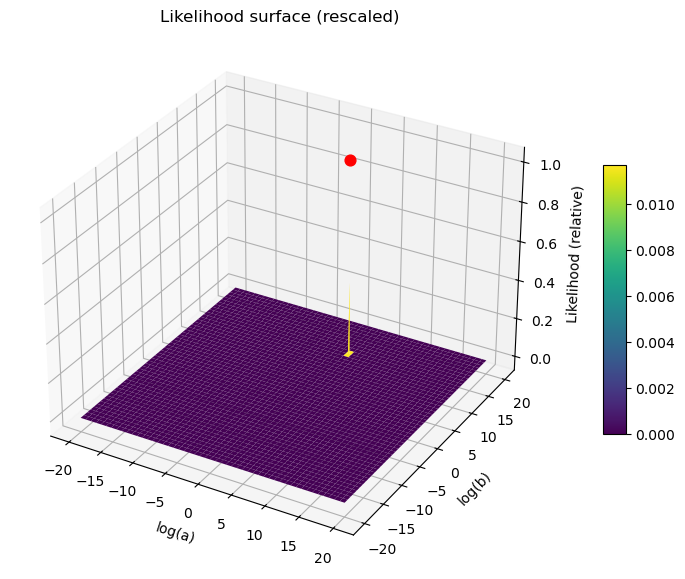

In [31]:
lik = np.exp(loglik - np.max(loglik))
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

A, B = np.meshgrid(np.log(a_grid), np.log(b_grid), indexing="ij")

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    A, B, lik,
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("log(a)")
ax.set_ylabel("log(b)")
ax.set_zlabel("Likelihood (relative)")
ax.set_title("Likelihood surface (rescaled)")

# mark MLE
ax.scatter(
    np.log(a_mle),
    np.log(b_mle),
    1.0,
    color="red",
    s=60
)

fig.colorbar(surf, shrink=0.5, aspect=12)

plt.show()


The likelihood seems to be mostly zero except for one peak. To get a better picture of the likelihood, we need to increase the grid resolution near the peak. Go back and change the grid to lie in the interval $[12, 20]$ for $a$ and $[120000, 200000]$ for $b$. 

503402.3817747312
15.701594084486949 151487.01656615367


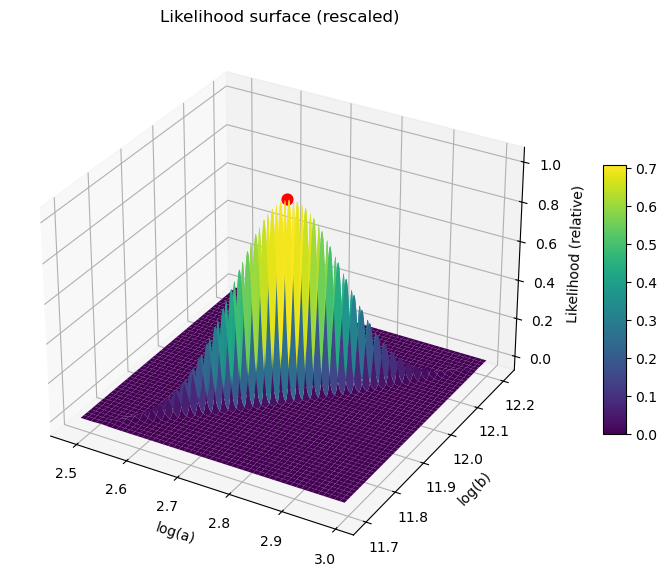

In [ ]:
x = d['dct'].to_numpy()
n = d['popm'].to_numpy()
nmx = n-x
N = len(x)

gridres = 400
#loga_low = np.log(1) #use this for getting good enough resolution for obtaining the maximizer
#loga_high = np.log(100) #use this for getting good enough resolution for obtaining the maximizer
loga_low =  np.log(12) #for getting a good plot of the likelihood surface, use this
loga_high = np.log(20) #for getting a good plot of the likelihood surface, use this
#loga_low = -20 #try this first (it does not give an accurate MLE because of poor resolution in the grid)
#loga_high = 20 #try this first (it does not give an accurate MLE because of poor resolution in the grid)

#logb_low = np.log(50000) #use this for getting good enough resolution for obtaining the maximizer
#logb_high = np.log(300000) #use this for getting good enough resolution for obtaining the maximizer
logb_low = np.log(120000) #for getting a good plot of the likelihood surface, use this
logb_high = np.log(200000) #for getting a good plot of the likelihood surface, use this
#logb_low = -20 #try this first (it does not give an accurate MLE because of poor resolution in the grid)
#logb_high = 20 #try this first (it does not give an accurate MLE because of poor resolution in the grid)
a_grid = np.exp(np.linspace(loga_low, loga_high, gridres))
b_grid = np.exp(np.linspace(logb_low, logb_high, gridres))

logB_ab = betaln(a_grid[:, None], b_grid[None, :]) #this is a gridres by gridres matrix where the (i, j)th entry is log(B(a_grid[i], b_grid[j]))

loglik = np.empty((gridres, gridres), dtype = float)

for ia, a in enumerate(a_grid): 
    s = betaln(x[:, None] + a, nmx[:, None] + b_grid[None, :]).sum(axis = 0)
    loglik[ia, :] = s - N*logB_ab[ia, :]

idx = np.unravel_index(np.argmax(loglik), loglik.shape)
#smallest negative loglikelihood: 
print(-np.max(loglik))
a_mle = a_grid[idx[0]]
b_mle = b_grid[idx[1]]
print(a_mle, b_mle)

lik = np.exp(loglik - np.max(loglik))
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

A, B = np.meshgrid(np.log(a_grid), np.log(b_grid), indexing="ij")

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    A, B, lik,
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("log(a)")
ax.set_ylabel("log(b)")
ax.set_zlabel("Likelihood (relative)")
ax.set_title("Likelihood surface (rescaled)")

# mark MLE
ax.scatter(
    np.log(a_mle),
    np.log(b_mle),
    1.0,
    color="red",
    s=60
)

fig.colorbar(surf, shrink=0.5, aspect=12)

plt.show()

With the estimates of $a$ and $b$ obtained by grid maximization as above, we can compute the Bayes estimates for each county. 

In [33]:
a = a_mle
b = b_mle
d['bayesestimate_margmle'] = (a + d['dct']) / (a + b + d['popm'])
#We can now flag the top 100 counties using the Bayesian estimate:
threshold_margmle = d['bayesestimate_margmle'].nlargest(100).iloc[-1]
d['bayeshigh_margmle'] = d['bayesestimate_margmle'] >= threshold_margmle
#Let us see how different this list is from the previous Bayes list: 

#Table of the top 100 counties flagged by both Bayesian estimate:
#2 by 2 cross-tabulation of the two lists:
ct = pd.crosstab(d['bayeshigh1'], d['bayeshigh_margmle'])
display(ct)

bayeshigh_margmle,False,True
bayeshigh1,,
False,3010,0
True,0,100


The list of the top 100 counties are the same in both the Bayes methods. 

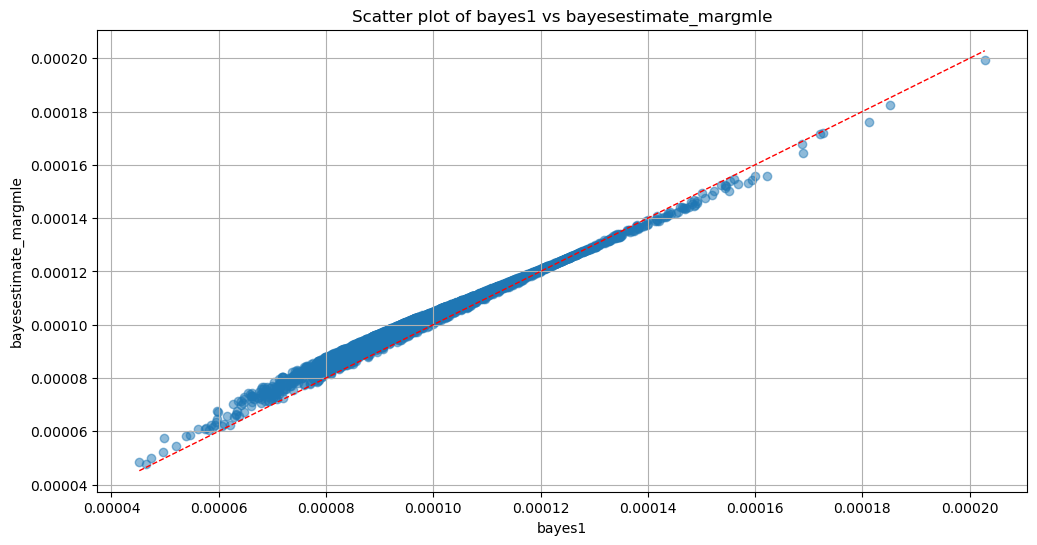

In [34]:
#scatter plot of d['bayes1'] vs d['bayesestimate_margmle']
plt.figure(figsize=(12,6))
plt.scatter(d['bayes1'], d['bayesestimate_margmle'], alpha = 0.5)
plt.xlabel('bayes1')
plt.ylabel('bayesestimate_margmle')
#superimpose y = x line
min_val = min(d['bayes1'].min(), d['bayesestimate_margmle'].min())
max_val = max(d['bayes1'].max(), d['bayesestimate_margmle'].max())
plt.plot([min_val, max_val], [min_val, max_val],
         linestyle='--', linewidth=1, color='red')
plt.title('Scatter plot of bayes1 vs bayesestimate_margmle')
plt.grid(True)
plt.show()

Below we check prediction accuracy of all the methods (naive frequentist proporition, and the Bayes estimates). We apply the methods to the data from 1980-84 and then predict the proportions for the period from 1985-89. 

In [35]:
d['naiveproportion1'] = d['dc'] / d['pop'] #these are the naive estimates (frequentist)

#Bayes Estimate ONE
proportions1_largecounties = d['naiveproportion1'][d['pop'] >= 300000] #filter out the high population counties
m1 = np.mean(proportions1_largecounties)
V1 = np.var(proportions1_largecounties)
a1 = ((m1*m1*(1-m1))/V1) - m1
b1 = (((1-m1)*(1-m1)*m1)/V1) - (1-m1)
print(f"Estimated a1: {a1}, Estimated b1: {b1}")

d['bayes1_firsthalf'] = (d['dc'] + a1)/(d['pop'] + a1 + b1)

#Bayes Estimate TWO
loga_low = np.log(1)
loga_high = np.log(100)

logb_low = np.log(50000)
logb_high = np.log(300000)

a_grid = np.exp(np.linspace(loga_low, loga_high, gridres))
b_grid = np.exp(np.linspace(logb_low, logb_high, gridres))

x = d['dc'].to_numpy()
n = d['pop'].to_numpy()
nmx = n-x
N = len(x)

logB_ab = betaln(a_grid[:, None], b_grid[None, :]) #this is a gridres by gridres matrix where the (i, j)th entry is log(B(a_grid[i], b_grid[j]))
loglik = np.empty((gridres, gridres), dtype = float)
for ia, a in enumerate(a_grid): 
    s = betaln(x[:, None] + a, nmx[:, None] + b_grid[None, :]).sum(axis = 0)
    loglik[ia, :] = s - N*logB_ab[ia, :]
idx = np.unravel_index(np.argmax(loglik), loglik.shape)
a_mle_1 = a_grid[idx[0]]
b_mle_1 = b_grid[idx[1]]
print(f"Estimated amle: {a_mle_1}, Estimated bmle: {b_mle_1}")


d['bayesestimate_margmle_firsthalf'] = (d['dc'] + a_mle_1)/(d['pop'] + a_mle_1 + b_mle_1)


#Proportions from the second half of the data:
d['proportion2'] = d['dc.2'] / d['pop.2']


#Proportions from the second half of the data:
d['proportion2'] = d['dc.2'] / d['pop.2']

#Prediction Accuracy:
diff_naiveproportion1 = d['naiveproportion1'] - d['proportion2']
sum_abs_diff_naiveproportion1 = diff_naiveproportion1.abs().sum()
sum_squared_diff_naiveproportion1 = (diff_naiveproportion1**2).sum()
kl_loss_naiveproportion1 = (d['proportion2'] * np.log(d['proportion2'] / (d['naiveproportion1'] + 1e-10) + 1e-10)).sum() + ((1 - d['proportion2']) * np.log((1 - d['proportion2']) / (1 - d['naiveproportion1'] + 1e-10) + 1e-10)).sum()
negloglik_naiveproportion1 = -(d['dc.2'] * np.log(d['naiveproportion1'] + 1e-10)).sum() - ((d['pop.2'] - d['dc.2']) * np.log(1 - d['naiveproportion1'] + 1e-10)).sum()


diff_bayes1 = d['bayes1_firsthalf'] - d['proportion2']
sum_abs_diff_bayes1 = diff_bayes1.abs().sum()
sum_squared_diff_bayes1 = (diff_bayes1**2).sum()
kl_loss_bayes1_firsthalf = (d['proportion2'] * np.log(d['proportion2'] / (d['bayes1_firsthalf'] + 1e-10) + 1e-10)).sum() + ((1 - d['proportion2']) * np.log((1 - d['proportion2']) / (1 - d['bayes1_firsthalf'] + 1e-10) + 1e-10)).sum()
negloglik_bayes1_firsthalf = -(d['dc.2'] * np.log(d['bayes1_firsthalf'] + 1e-10)).sum() - ((d['pop.2'] - d['dc.2']) * np.log(1 - d['bayes1_firsthalf'] + 1e-10)).sum() 

diff_bayes2 = d['bayesestimate_margmle_firsthalf'] - d['proportion2']
sum_abs_diff_bayes2 = diff_bayes2.abs().sum()
sum_squared_diff_bayes2 = (diff_bayes2**2).sum()
kl_loss_bayes2_firsthalf = (d['proportion2'] * np.log(d['proportion2'] / (d['bayesestimate_margmle_firsthalf'] + 1e-10) + 1e-10)).sum() + ((1 - d['proportion2']) * np.log((1 - d['proportion2']) / (1 - d['bayesestimate_margmle_firsthalf'] + 1e-10) + 1e-10)).sum()
negloglik_bayes2_firsthalf = -(d['dc.2'] * np.log(d['bayesestimate_margmle_firsthalf'] + 1e-10)).sum() - ((d['pop.2'] - d['dc.2']) * np.log(1 - d['bayesestimate_margmle_firsthalf'] + 1e-10)).sum() 



allresults_absdiff = np.array([sum_abs_diff_naiveproportion1, sum_abs_diff_bayes1, sum_abs_diff_bayes2])
allresults_squareddiff = np.array([sum_squared_diff_naiveproportion1, sum_squared_diff_bayes1, sum_squared_diff_bayes2])
allresults_klloss = np.array([kl_loss_naiveproportion1, kl_loss_bayes1_firsthalf, kl_loss_bayes2_firsthalf])
allresults_negloglik = np.array([negloglik_naiveproportion1, negloglik_bayes1_firsthalf, negloglik_bayes2_firsthalf])
print(allresults_absdiff)
print(allresults_squareddiff)
print(allresults_klloss)
print(allresults_negloglik)

Estimated a1: 9.642510227719821, Estimated b1: 203435.3366143135
Estimated amle: 14.551483398731948, Estimated bmle: 298655.83276364877
[0.12508483 0.1053034  0.10488608]
[1.29012723e-05 8.07678746e-06 8.00891733e-06]
[0.50184892 0.06705131 0.06625212]
[290602.92682912 282151.84239388 282097.23532142]


The accuracy of this second Empirical Bayes method based on marginal MLE is almost the same (but slightly smaller) compared to the previous 'Method of Moments' based approach. 

## Full Hierarchical Bayes

Instead of relying on methods such as the MLE or method of moments, we can use full probability, and place priors on $a$ and $b$. We will use the following noninformative prior:
\begin{align*}
    \log a, \log b \overset{\text{i.i.d}}{\sim} \text{uniform}(-\infty, \infty). 
\end{align*}
In other words, 
\begin{align*}
   f_{a, b}(a, b) \propto \frac{I\{a > 0, b > 0\}}{a b}. 
\end{align*}
The posterior density of $(a, b)$ is therefore given by: 
\begin{align*}
   f_{a, b \mid \text{data}}(a, b) \propto \frac{I\{a > 0, b > 0\}}{a b} \times {n \choose x} \frac{B(x + a, n-x + b)}{B(a, b)} \propto \frac{I\{a > 0, b > 0\}}{a b} \frac{B(x + a, n-x + b)}{B(a, b)} 
\end{align*}
We compute the unnormalized posterior for each point $(a, b)$ in the same grid that we previously used for marginal maximum likelihood. After that, we normalize it by dividing each weight by the sum of the unnormalized posterior weights. This gives a discrete approximation for the posterior of $a$ and $b$, which we can use for computing the posterior means, obtaining posterior samples of $a, b$ etc. 

In [36]:
from scipy.special import logsumexp

In [37]:
#same grids that we used for the marginal MLE estimation:
loga_low = np.log(1)
loga_high = np.log(100)

logb_low = np.log(50000)
logb_high = np.log(300000)

a_grid = np.exp(np.linspace(loga_low, loga_high, gridres))
b_grid = np.exp(np.linspace(logb_low, logb_high, gridres))

x = d['dct'].to_numpy()
n = d['popm'].to_numpy()
nmx = n-x
N = len(x)

log_post_ab = np.empty((len(a_grid), len(b_grid)))
log_b = np.log(b_grid)

for i, a in enumerate(a_grid):
    ll = np.sum(betaln(x[:, None] + a, nmx[:, None] + b_grid[None, :]),axis=0) - N * betaln(a, b_grid)  
    log_post_ab[i, :] = ll -  np.log(a) - log_b #log of the unnormalized posterior

post_ab = np.exp(log_post_ab - logsumexp(log_post_ab))

a_postmean = np.sum(a_grid[:, None] * post_ab)
b_postmean = np.sum(b_grid[None, :] * post_ab)
print(f"Estimated a (post mean): {a_postmean}, Estimated b (post mean): {b_postmean}")


Estimated a (post mean): 15.602962225114446, Estimated b (post mean): 150546.7020690343


We shall get back to this full Bayes model in the next lecture. 